# TP4 :  Learning on a low budget
**Théo Rudkiewicz, Cyriaque Rousselot**

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data samples are available for training, say 

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. 

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. 
(To make your task easier, we provide you with some data (named `test_dataset` in the code) that you can use to test your model, but you **must not** use it to train your model).

We also assume that we have a limited computational budget.

The goal of this practical session is to guide you through different methods that will help you get better results from few resources (data & compute).

In this practical, we will use the `resnet18` architecture. We will use models from the [pytorch vision hub ](https://pytorch.org/vision/stable/models.html#).

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide 7 files : 
1. This Notebook
2. `utils.py`
3. `last_layer_finetune.pth` (the file **must be of size less than 5Mo**)
4. `daug_resnet.pth` (the file **must be of size less than 50Mo**)
5. `final_model.pth` (the file **must be of size less than 50Mo**)
6. `drawing_lora.png`
7. `cutmix.png`

If the code you defined passes all our tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).  

<div class="alert alert-info">  Example of answer  </div>

In [1]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchmetrics.classification import BinaryAccuracy, Accuracy, ConfusionMatrix
# you can install torchmetrics with `pip install torchmetrics`


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


north_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)
base_model = models.resnet18()

## Question 1 : 
>  Change the last layer of the resnet model so that its size fits the problem. 

In [3]:
# Hint 
print(base_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
n_in = base_model.fc.in_features
print(n_in) # should be 512
base_model.fc = nn.Linear(n_in, 2)

512


In [5]:
assert (
    base_model.fc.out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2: 
> Train the last layer of a randomly initialized resnet model. Provide a function precompute_features in `utils.py` that creates a new dataset from the features precomputed by the model.

Intermediate question :  Provide the training process in the notebook with training curve. Comment on the accuracy. 

In [6]:
def precompute_features(
    model: models.ResNet, 
    dataset: torch.utils.data.Dataset, 
    device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is 
    the rest of the model, it is not necessary to recompute $g(x)$ at 
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and 
    create a new dataset 
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation
    
    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    model = model.to(device)
    model.eval()  # to go faster (dont compute the grads) and to set dropout as 0

    get_feats = torch.nn.Sequential(*list(model.children())[:-1]) # we remove the last layer (the one we wanna train)

    get_feats.to(device)

    feats = []
    labs = []

    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            feat = get_feats(images)
            feat = feat.view(feat.size(0), -1)
            feats.append(feat.cpu())
            labs.append(batch[1].cpu())

    features = torch.cat(feats)
    labels = torch.cat(labs)

    return TensorDataset(features, labels)

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_21887/1227421568.py:6: SyntaxWarning: invalid escape sequence '\c'
  """


In [7]:
from torch.utils.data import DataLoader, TensorDataset

In [8]:
from torch.utils.data import DataLoader, TensorDataset
from utils import precompute_features

base_model.to(device)

train_feat_dataset = precompute_features(base_model, north_dataset, device)
test_feat_dataset = precompute_features(base_model, test_dataset, device)

train_dataloader = DataLoader(train_feat_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_feat_dataset, batch_size=64, shuffle=False) 

In [11]:
from tqdm import trange

def simple_trainer(model, criterion, dataloader, test_dataloader, epochs=600, lr=1e-3, device="cuda"):
    """Classical trainer for a torch model with training & test evaluation
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()  # Just in case

    all_loss = []
    all_loss_test = []
    all_acc = []
    all_acc_test = []

    bar = trange(epochs, desc="Training", leave=True)

    for epoch in bar:
        model.train()
        epoch_loss = 0
        correct_train = 0
        num_batches = 0
        total_train = 0

        for batch in dataloader:
            X, y = batch[0].to(device), batch[1].to(device)
            y_one_hot = torch.nn.functional.one_hot(y, num_classes=2).float()

            optimizer.zero_grad()
            pred = model(X)

            loss = criterion(pred, y_one_hot)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            predicted_labels = torch.argmax(pred, dim=1)
            correct_train += (predicted_labels == y).sum().item()
            total_train += y.size(0)

        avg_loss = epoch_loss / num_batches
        train_acc = correct_train / total_train

        all_loss.append(avg_loss)
        all_acc.append(train_acc)

        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        num_batches_test = 0

        with torch.no_grad():
            for batch in test_dataloader:
                X_test, y_test = batch[0].to(device), batch[1].to(device)
                y_test_one_hot = torch.nn.functional.one_hot(y_test, num_classes=2).float()

                pred_test = model(X_test)
                loss_test = criterion(pred_test, y_test_one_hot)

                test_loss += loss_test.item()
                num_batches_test += 1

                predicted_labels_test = torch.argmax(pred_test, dim=1)
                correct_test += (predicted_labels_test == y_test).sum().item()
                total_test += y_test.size(0)

        avg_loss_test = test_loss / num_batches_test
        test_acc = correct_test / total_test

        all_loss_test.append(avg_loss_test)
        all_acc_test.append(test_acc)

        bar.set_description(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Acc: {train_acc:.4f} | Test Loss: {avg_loss_test:.4f} - Test Acc: {test_acc:.4f}")

    return (all_loss, all_loss_test, all_acc, all_acc_test)

In [12]:

model_lin = nn.Linear(512, 2)
epochs=3000
criterion = nn.BCEWithLogitsLoss()

losses = simple_trainer(model_lin, criterion, train_dataloader, test_dataloader= test_dataloader, lr=1e-3, epochs=epochs)

Epoch 3000/3000 - Loss: 0.0895 - Acc: 1.0000 | Test Loss: 0.6542 - Test Acc: 0.6905: 100%|██████████| 3000/3000 [00:13<00:00, 218.06it/s]


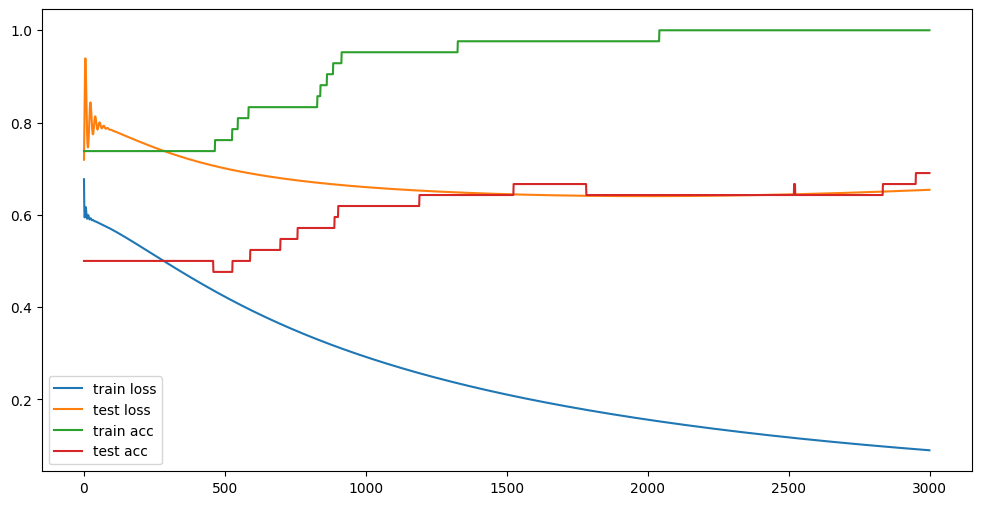

In [13]:
import matplotlib.pyplot as plt

def plot_losses(losses):
    plt.figure(figsize=(12,6))
    plt.plot(losses[0], label="train loss")
    plt.plot(losses[1], label="test loss")

    plt.plot(losses[2], label="train acc")
    plt.plot(losses[3], label="test acc")
    plt.legend()
    plt.show()

plot_losses(losses)

<div class="alert alert-info">  Here, we can see that the model reach 100% accuracy on the train set with $\approx$ 2000 epochs, the train loss looks like a "normal" loss, decreasing at a normal rate. The test loss is decreasing too but at a slower rate and the test acc stagnate around 70% </div>

<div class="alert alert-info">  Example of answer  </div>

## Question 3 : 
> Now start from a pretained model on Imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve. 

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `utils.py` containing only the last layer class `LastLayer` inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `last_layer_finetune.pth` file containing __only the last layer weights__ ( we will check the size) 
 
 We will test your model on final accuracy on a test set. 
 

In [14]:
class LastLayer(nn.Module):
    def __init__(self):
        super(LastLayer, self).__init__()
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.fc(x)

In [15]:
layer_fc = LastLayer()
torch.save(base_model.fc.state_dict(), "lastlayer.pth")

In [22]:
class LastLayer(nn.Module):
    def __init__(self):
        super(LastLayer, self).__init__()
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.fc(x)

layer_fc = LastLayer()
torch.save(layer_fc.fc.state_dict(), "lastlayer.pth")

fc = LastLayer()

fc.load_state_dict(torch.load("lastlayer.pth"), strict=False)

assert fc(torch.randn(1,512)).shape[-1] == 2


In [26]:
layer_fc = LastLayer()
torch.save(layer_fc.fc.state_dict(), "lastlayer.pth")


resnet = models.resnet18(weights="DEFAULT")
fc = LastLayer()  # !  Important : No argument
fc.load_state_dict(torch.load("lastlayer.pth"), strict=False)
resnet.fc = fc
resnet.eval()


train_feat_dataset = precompute_features(resnet, north_dataset, device)
test_feat_dataset = precompute_features(resnet, test_dataset, device)

train_dataloader = DataLoader(train_feat_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_feat_dataset, batch_size=64, shuffle=False) 

epochs=2000
criterion = nn.BCEWithLogitsLoss()


losses = simple_trainer(layer_fc, criterion, train_dataloader, test_dataloader= test_dataloader, lr=1e-3, epochs=epochs)


torch.save(fc.fc.state_dict(), "last_layer_finetune.pth")


Epoch 2000/2000 - Loss: 0.0015 - Acc: 1.0000 | Test Loss: 0.6098 - Test Acc: 0.8095: 100%|██████████| 2000/2000 [00:08<00:00, 224.19it/s]


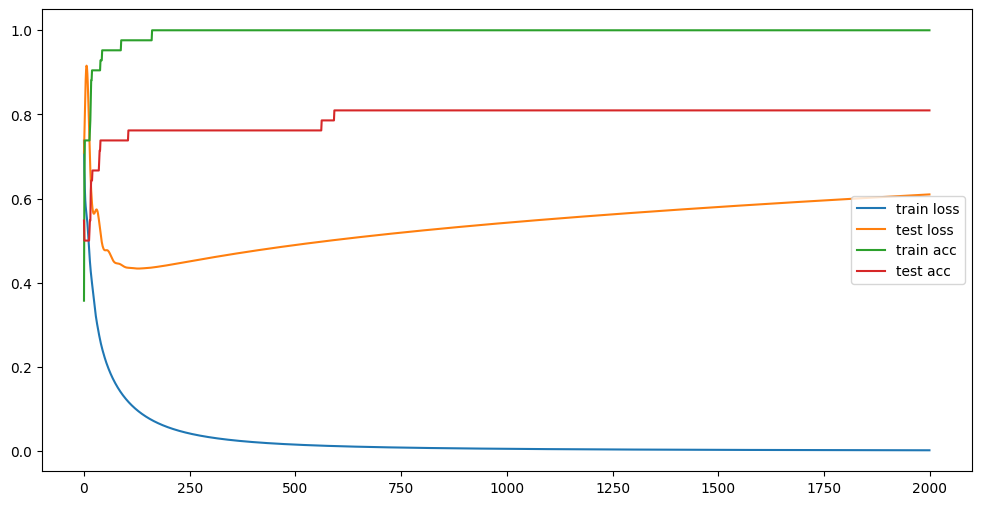

In [27]:
plot_losses(losses)

<div class="alert alert-info">  Now we can clearly see a big difference with what we've done in a first place. Here the accuracy goes to 1 (on train) after less than 250 epochs (1000 for the one with randomly initialized resnet) and the test set quickly reach 0.7 accuracy and goes up to 0.8. We can see that after a few epochs, the model start to overfit (test loss is increasing)</div>

## Question 4 : 
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  (We are perfectly fine if you use an external library **for this question only**, and of course use it in the next questions). (Warning : without data augmentation it may not improve the accuracy.)

Intermediate question : Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the `drawing_lora.png` file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)

In [28]:
!pip install loralib

In [ ]:
torch.save(lora_model.state_dict(), "lora_resnet.pth")

## Question 5 : 
In order to better train our LORA weights, let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them in your training pipeline.

 Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing `cutmix.png`. 


  Provide one file : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a `daug_resnet.pth` file containing the weight of the ResNet18 after DAUG  (  !  It  has to be of the class ResNet so you have to merge LoRA weights with the ResNet18 weights)

In [ ]:
## Data Augmentation
from torchvision.transforms import v2

In [ ]:
lora_model = NotImplementedError  # <YOUR CODE>
assert isinstance(lora_model, models.ResNet)

In [ ]:
torch.save(lora_model.state_dict(), "daug_resnet.pth")

## Question 6 : (BONUS) 
> Do the best you can : improve performance on test set while keeping ResNet 18 architecture, or decrease the size of the model

Provide a file  `final_model.pth` containing the weights of the final model and provide the class `FinalModel()` in the `utils.py` file. 